In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simulator import simulate

In [2]:
def compute_summary(I, R, H):
    eps = 1e-6

    # --- Infection ---

    t = np.arange(len(I))

    # 1) EARLY GROWTH RATE
    t_early = t[:min(20, len(I))]
    slope = np.polyfit(t_early, np.log(I[:len(t_early)] + eps), 1)[0]

    # 2) NORMALISED INFECTION PEAK
    peak_I = np.max(I)
    peak_norm_I = peak_I / (np.mean(I[:10]) + eps)

    # 3) TIME TO PEAK
    t_peak = np.argmax(I)

    # 4) TOTAL BURDEN
    auc_I = np.sum(I)

    # 5) DECAY RATE AFTER PEAK
    if t_peak < len(I) - 5:
        t_decay = t[t_peak:]
        I_decay = I[t_peak:]
        mask = I_decay > 0
        if np.sum(mask) > 5:
            decay_slope = np.polyfit(
                t_decay[mask],
                np.log(I_decay[mask] + eps),
                1
            )[0]
        else:
            decay_slope = 0.0
    else:
        decay_slope = 0.0

    # --- Rewiring ---

    total_R = np.sum(R)
    peak_R = np.max(R)

    # 6) REWIRING PER INFECTION
    rw_per_inf = total_R / (auc_I + eps)

    # 7) TOTAL REWIRING PEAK
    peak_rw_norm = peak_R / len(R)

    # 8) CORRELATION (I-R COUPLING)
    corr_IR = np.corrcoef(I, R)[0, 1] if np.std(R) > 0 else 0.0

    # --- Network ---

    degrees = np.arange(len(H))
    total_nodes = np.sum(H)

    # 9) NETWORK DEGREE MEAN
    mean_deg = np.dot(degrees, H) / total_nodes

    # 10) NETWORK DEGREE VARIANCE
    var_deg = np.dot(H, (degrees - mean_deg) ** 2) / total_nodes

    return np.array([
        slope,
        peak_norm_I,
        t_peak,
        auc_I,
        decay_slope,
        rw_per_inf,
        peak_rw_norm,
        corr_IR,
        mean_deg,
        var_deg
    ])

In [3]:
infected_df = pd.read_csv("data\\infected_timeseries.csv")
rewire_df = pd.read_csv("data\\rewiring_timeseries.csv")
degree_df = pd.read_csv("data\\final_degree_histograms.csv")


def get_observed_summaries():
    summaries = []

    for rep_id in infected_df["replicate_id"].unique():
        I = infected_df[infected_df.replicate_id == rep_id]["infected_fraction"].values
        R = rewire_df[rewire_df.replicate_id == rep_id]["rewire_count"].values

        H_df = degree_df[degree_df.replicate_id == rep_id]
        H = np.zeros(31)
        for _, row in H_df.iterrows():
            H[int(row["degree"])] = row["count"]

        summaries.append(compute_summary(I, R, H))

    return np.array(summaries)

summaries_obs = get_observed_summaries()
S_obs = np.mean(summaries_obs, axis=0)

scale = np.std(summaries_obs, axis=0) + 1e-6

In [4]:
def compute_distance(S_sim, S_obs, scale):
    return np.linalg.norm((S_sim - S_obs) / scale, axis=1)

In [5]:
def naive_abc(n_samples=50000):
    rng = np.random.default_rng(3247)

    thetas = np.empty((n_samples, 3))
    summaries = np.empty((n_samples, 10))

    # Parameter generation step
    thetas[:, 0] = rng.uniform(0.05, 0.5, n_samples)
    thetas[:, 1] = rng.uniform(0.02, 0.2, n_samples)
    thetas[:, 2] = rng.uniform(0.0, 0.8, n_samples)

    for i in range(n_samples):
        I, R, H = simulate(*thetas[i], rng=rng)
        summaries[i] = compute_summary(I, R, H)

    return thetas, summaries

In [6]:
thetas, S_sim = naive_abc()

In [7]:
distances = compute_distance(S_sim, S_obs, scale)

In [8]:
# Selection step
epsilon = np.quantile(distances, 0.05)
posterior_samples = thetas[distances < epsilon]

In [9]:
for i, name in enumerate(["β", "γ", "ρ"]):
    data = posterior_samples[:, i]

    mean = np.mean(data)
    lower, upper = np.quantile(data, [0.025, 0.975])

    print(f"{name}:")
    print(f"Posterior Mean = {mean:.4f}")
    print(f"95% credible interval = ({lower:.4f}, {upper:.4f})")
    print()

β:
Posterior Mean = 0.2194
95% credible interval = (0.1050, 0.3658)

γ:
Posterior Mean = 0.0902
95% credible interval = (0.0601, 0.1263)

ρ:
Posterior Mean = 0.3170
95% credible interval = (0.1540, 0.4937)



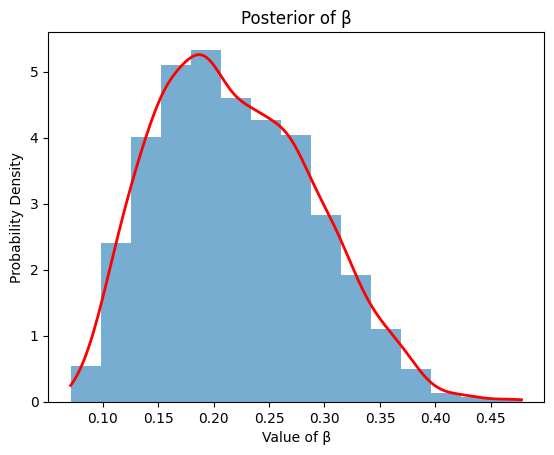

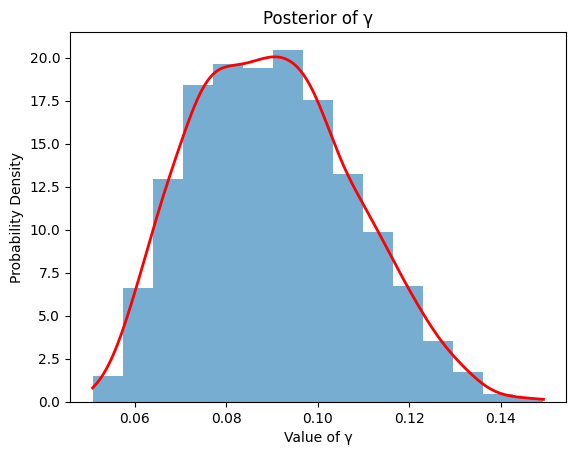

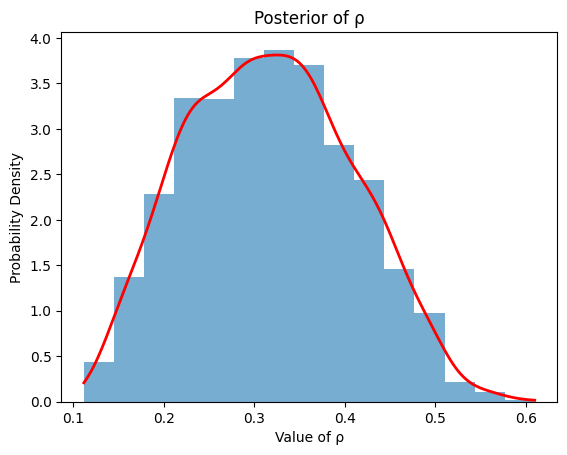

In [10]:
from scipy.stats import gaussian_kde

for i, name in enumerate(["β", "γ", "ρ"]):
    data = posterior_samples[:, i]
    plt.hist(data, bins=15, density=True, alpha=0.6)
    
    kde = gaussian_kde(data)
    xs = np.linspace(data.min(), data.max(), 200)
    plt.xlabel(f"Value of {name}")
    plt.ylabel("Probability Density")
    plt.plot(xs, kde(xs), 'r-', linewidth=2)
    plt.title(f"Posterior of {name}")
    plt.show()

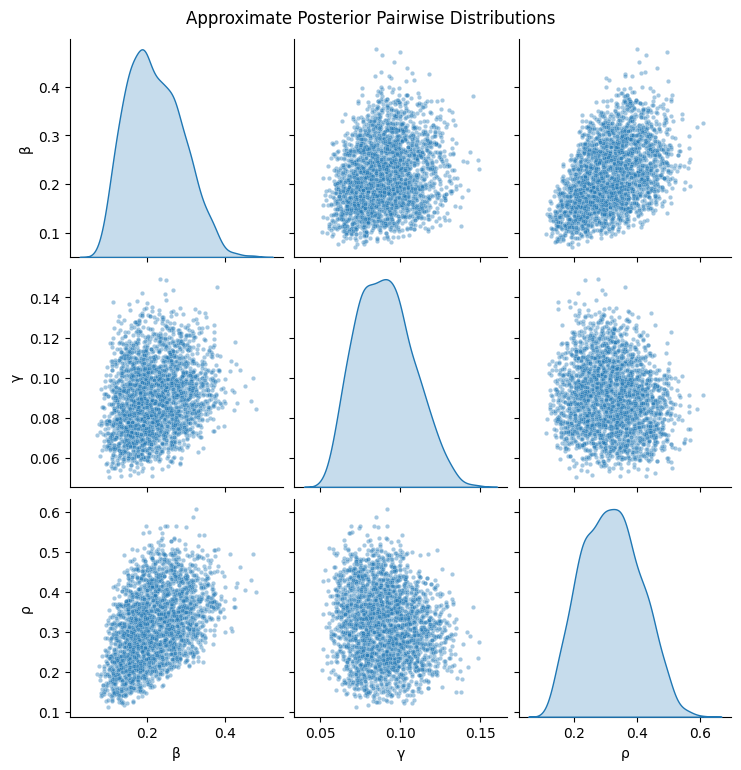

In [11]:
import seaborn as sns

df_post = pd.DataFrame(posterior_samples, columns=["β", "γ", "ρ"])

sns.pairplot(
    df_post,
    diag_kind="kde",
    plot_kws={"s": 10, "alpha": 0.4}
)

plt.suptitle("Approximate Posterior Pairwise Distributions", y=1.02)
plt.show()

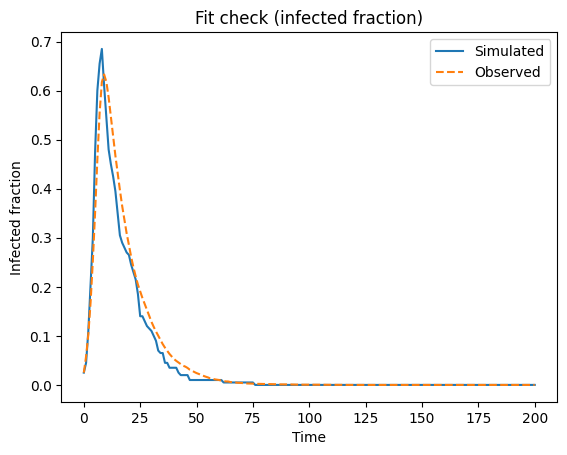

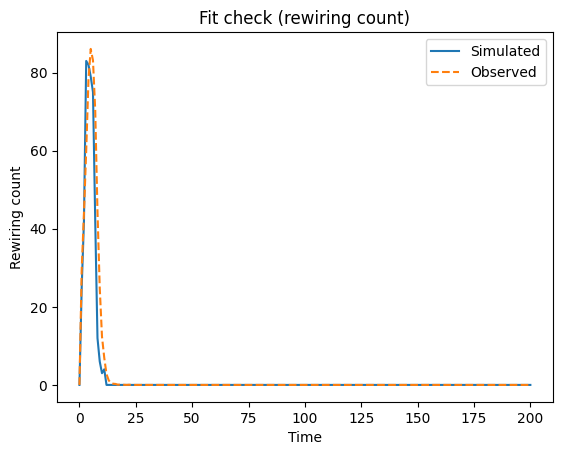

In [21]:
# Sanity check

theta_mean = np.average(posterior_samples, axis=0)

I_sim, R_sim, H_sim = simulate(*theta_mean)

I_obs = infected_df.groupby("time")["infected_fraction"].mean().values

plt.plot(I_sim, label="Simulated")
plt.plot(I_obs, label="Observed", linestyle="--")

plt.title("Fit check (infected fraction)")
plt.xlabel("Time")
plt.ylabel("Infected fraction")
plt.legend()
plt.show()

R_obs = rewire_df.groupby("time")["rewire_count"].mean().values

t = np.arange(min(len(R_sim), len(R_obs)))

plt.plot(t, R_sim[:len(t)], label="Simulated")
plt.plot(t, R_obs[:len(t)], label="Observed", linestyle="--")

plt.title("Fit check (rewiring count)")
plt.xlabel("Time")
plt.ylabel("Rewiring count")
plt.legend()
plt.show()